# 🎯 Customer Segmentation — RFM Analysis

**Pipeline:** Data Loading → Preprocessing → EDA → RFM Calculation → Scoring → Segmentation → Visualisasi → Business Insights

**Dataset:** Raw sales transactions 2025 (2000 transaksi, 812 customers, 5 region Myanmar)

---

## 0. Setup & Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

PALETTE = {
    'Champions'        : '#2ecc71',
    'Loyal Customers'  : '#27ae60',
    'Potential Loyalist': '#82e0aa',
    'At Risk'          : '#e67e22',
    'Cant Lose Them'   : '#e74c3c',
    'Hibernating'      : '#95a5a6',
    'Lost'             : '#7f8c8d',
    'New Customers'    : '#3498db',
    'Promising'        : '#5dade2',
    'Need Attention'   : '#f39c12',
    'About To Sleep'   : '#d35400',
}

print('✅ Library siap digunakan')

✅ Library siap digunakan


---
## 1. Data Loading

In [4]:
df_raw = pd.read_csv('/content/raw_rfm_sales_transactions_(V2).csv')

print(f'Shape        : {df_raw.shape}')
print(f'Kolom        : {df_raw.columns.tolist()}')
print(f'Memori (MB)  : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f}')
df_raw.head()

Shape        : (2000, 10)
Kolom        : ['Transaction ID', 'Date', 'Product ID', 'Product Name', 'Product Category', 'Quantity', 'PPU', 'Amount', 'Customer ID', 'Region']
Memori (MB)  : 1.09


,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount,Customer ID,Region
0,T000001,01-01-2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,13,"25,000","325,000",Customer-190,Yangon
1,T000002,01-01-2025,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,500,"25,000","12,500,000",Customer-985,Bago
2,T000003,01-01-2025,PROD-009,Adjustable Monitor Arm,Furniture,25,"180,000","4,500,000",Customer-625,Mandalay
3,T000004,01-01-2025,PROD-002,Wireless Mechanical Keyboard,Electronics,41,"350,000","14,350,000",Customer-882,Yangon
4,T000005,01-01-2025,PROD-009,Adjustable Monitor Arm,Furniture,28,"180,000","5,040,000",Customer-801,Bago


In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    2000 non-null   object
 1   Date              2000 non-null   object
 2   Product ID        2000 non-null   object
 3   Product Name      2000 non-null   object
 4   Product Category  2000 non-null   object
 5   Quantity          2000 non-null   int64 
 6   PPU               2000 non-null   object
 7   Amount            2000 non-null   object
 8   Customer ID       2000 non-null   object
 9   Region            2000 non-null   object
dtypes: int64(1), object(9)
memory usage: 156.4+ KB


In [6]:
df_raw.describe(include='all')

,Transaction ID,Date,Product ID,Product Name,Product Category,Quantity,PPU,Amount,Customer ID,Region
count,2000,2000,2000,2000,2000,2000.000000,2000,2000,2000,2000
unique,2000,177,10,10,3,NaN,10,463,812,5
top,T001984,26-02-2025,PROD-006,A4 Printer Paper (500 Sheets),Electronics,NaN,"25,000","7,000,000",Customer-670,Yangon
freq,1,19,228,228,964,NaN,228,22,10,594
mean,NaN,NaN,NaN,NaN,NaN,61.916000,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,106.596916,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,17.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,44.000000,NaN,NaN,NaN,NaN


---
## 2. Preprocessing

### 2.1 Missing Values

In [7]:
missing = df_raw.isnull().sum().rename('Missing').to_frame()
missing['%'] = (missing['Missing'] / len(df_raw) * 100).round(2)
print(missing)
print(f'\n✅ Total missing values: {missing["Missing"].sum()}')

                  Missing    %
Transaction ID          0  0.0
Date                    0  0.0
Product ID              0  0.0
Product Name            0  0.0
Product Category        0  0.0
Quantity                0  0.0
PPU                     0  0.0
Amount                  0  0.0
Customer ID             0  0.0
Region                  0  0.0

✅ Total missing values: 0


### 2.2 Duplikat

In [8]:
n_dup = df_raw.duplicated().sum()
n_tid_dup = df_raw.duplicated(subset='Transaction ID').sum()
print(f'Baris duplikat penuh   : {n_dup}')
print(f'Transaction ID duplikat: {n_tid_dup}')

Baris duplikat penuh   : 0
Transaction ID duplikat: 0


### 2.3 Tipe Data & Parsing

In [9]:
df = df_raw.copy()

# Parse tanggal (format dd-mm-yyyy)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Hapus koma & konversi Amount / PPU ke numerik
df['Amount'] = df['Amount'].astype(str).str.replace(',', '', regex=False).astype(float)
df['PPU']    = df['PPU'].astype(str).str.replace(',', '', regex=False).astype(float)

# Rename agar konsisten
df.rename(columns={
    'Transaction ID'  : 'transaction_id',
    'Date'            : 'date',
    'Product ID'      : 'product_id',
    'Product Name'    : 'product_name',
    'Product Category': 'category',
    'Quantity'        : 'quantity',
    'PPU'             : 'ppu',
    'Amount'          : 'amount',
    'Customer ID'     : 'customer_id',
    'Region'          : 'region',
}, inplace=True)

print('Tipe data setelah parsing:')
print(df.dtypes)
df.head(3)

Tipe data setelah parsing:
transaction_id            object
date              datetime64[ns]
product_id                object
product_name              object
category                  object
quantity                   int64
ppu                      float64
amount                   float64
customer_id               object
region                    object
dtype: object


,transaction_id,date,product_id,product_name,category,quantity,ppu,amount,customer_id,region
0,T000001,2025-01-01,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,13,25000.0,325000.0,Customer-190,Yangon
1,T000002,2025-01-01,PROD-006,A4 Printer Paper (500 Sheets),Office Supplies,500,25000.0,12500000.0,Customer-985,Bago
2,T000003,2025-01-01,PROD-009,Adjustable Monitor Arm,Furniture,25,180000.0,4500000.0,Customer-625,Mandalay


### 2.4 Outlier & Validasi

In [10]:
# Cek amount negatif / nol
print(f'Amount ≤ 0 : {(df["amount"] <= 0).sum()}')
print(f'Quantity ≤ 0: {(df["quantity"] <= 0).sum()}')

# Cek konsistensi: amount ≈ quantity * ppu
diff = (df['amount'] - df['quantity'] * df['ppu']).abs()
print(f'Mismatch amount vs qty*ppu (tol 1): {(diff > 1).sum()}')

# Range tanggal
print(f'\nTanggal: {df["date"].min().date()} → {df["date"].max().date()}')

Amount ≤ 0 : 0
Quantity ≤ 0: 0
Mismatch amount vs qty*ppu (tol 1): 0

Tanggal: 2025-01-01 → 2025-12-31


Outlier amount (IQR): 272 baris (13.6%)


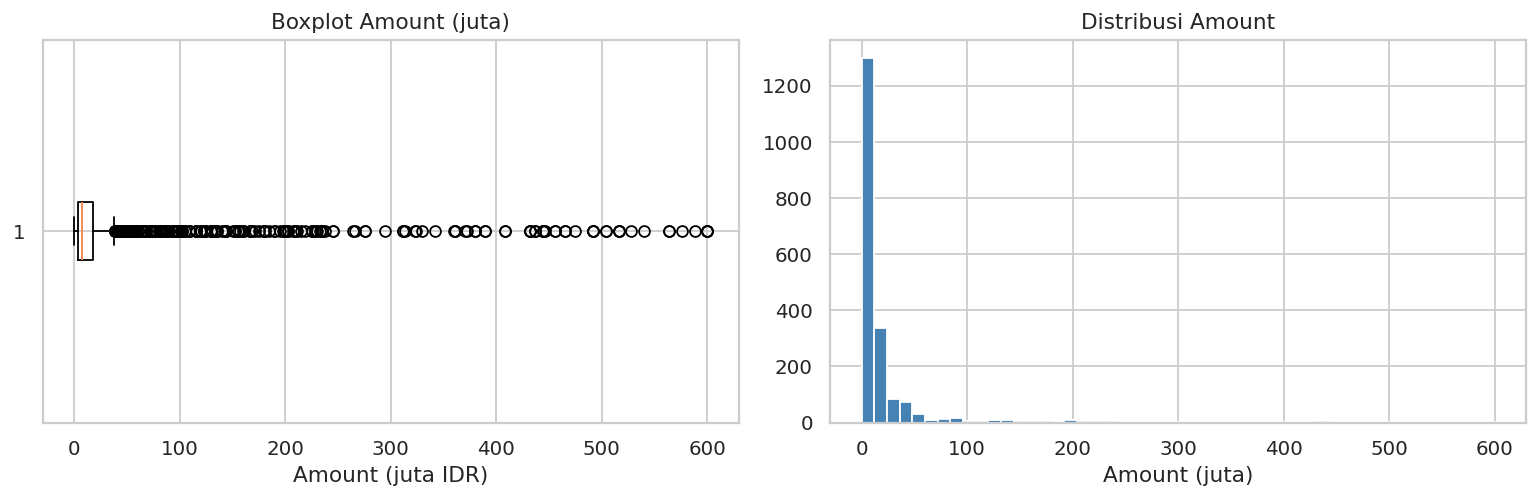

In [11]:
# Outlier Amount — IQR method (deteksi saja, tidak di-drop)
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['amount'] < Q1 - 1.5*IQR) | (df['amount'] > Q3 + 1.5*IQR)
print(f'Outlier amount (IQR): {outlier_mask.sum()} baris ({outlier_mask.mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['amount'] / 1e6, vert=False)
axes[0].set_title('Boxplot Amount (juta)')
axes[0].set_xlabel('Amount (juta IDR)')
axes[1].hist(df['amount'] / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Distribusi Amount')
axes[1].set_xlabel('Amount (juta)')
plt.tight_layout()
plt.show()

---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Overview Dataset

In [12]:
print('=== RINGKASAN DATASET ===')
print(f'Total transaksi  : {len(df):,}')
print(f'Unique customers : {df["customer_id"].nunique():,}')
print(f'Unique products  : {df["product_id"].nunique():,}')
print(f'Total revenue    : {df["amount"].sum()/1e9:.2f} Miliar')
print(f'Avg order value  : {df["amount"].mean()/1e3:.1f} Ribu')
print(f'Periode          : {df["date"].min().date()} s/d {df["date"].max().date()}')
print(f'Regions          : {", ".join(df["region"].unique())}')
print(f'Kategori produk  : {", ".join(df["category"].unique())}')

=== RINGKASAN DATASET ===
Total transaksi  : 2,000
Unique customers : 812
Unique products  : 10
Total revenue    : 59.85 Miliar
Avg order value  : 29925.8 Ribu
Periode          : 2025-01-01 s/d 2025-12-31
Regions          : Yangon, Bago, Mandalay, Naypyitaw, Taunggyi
Kategori produk  : Office Supplies, Furniture, Electronics


### 3.2 Revenue Trend Bulanan

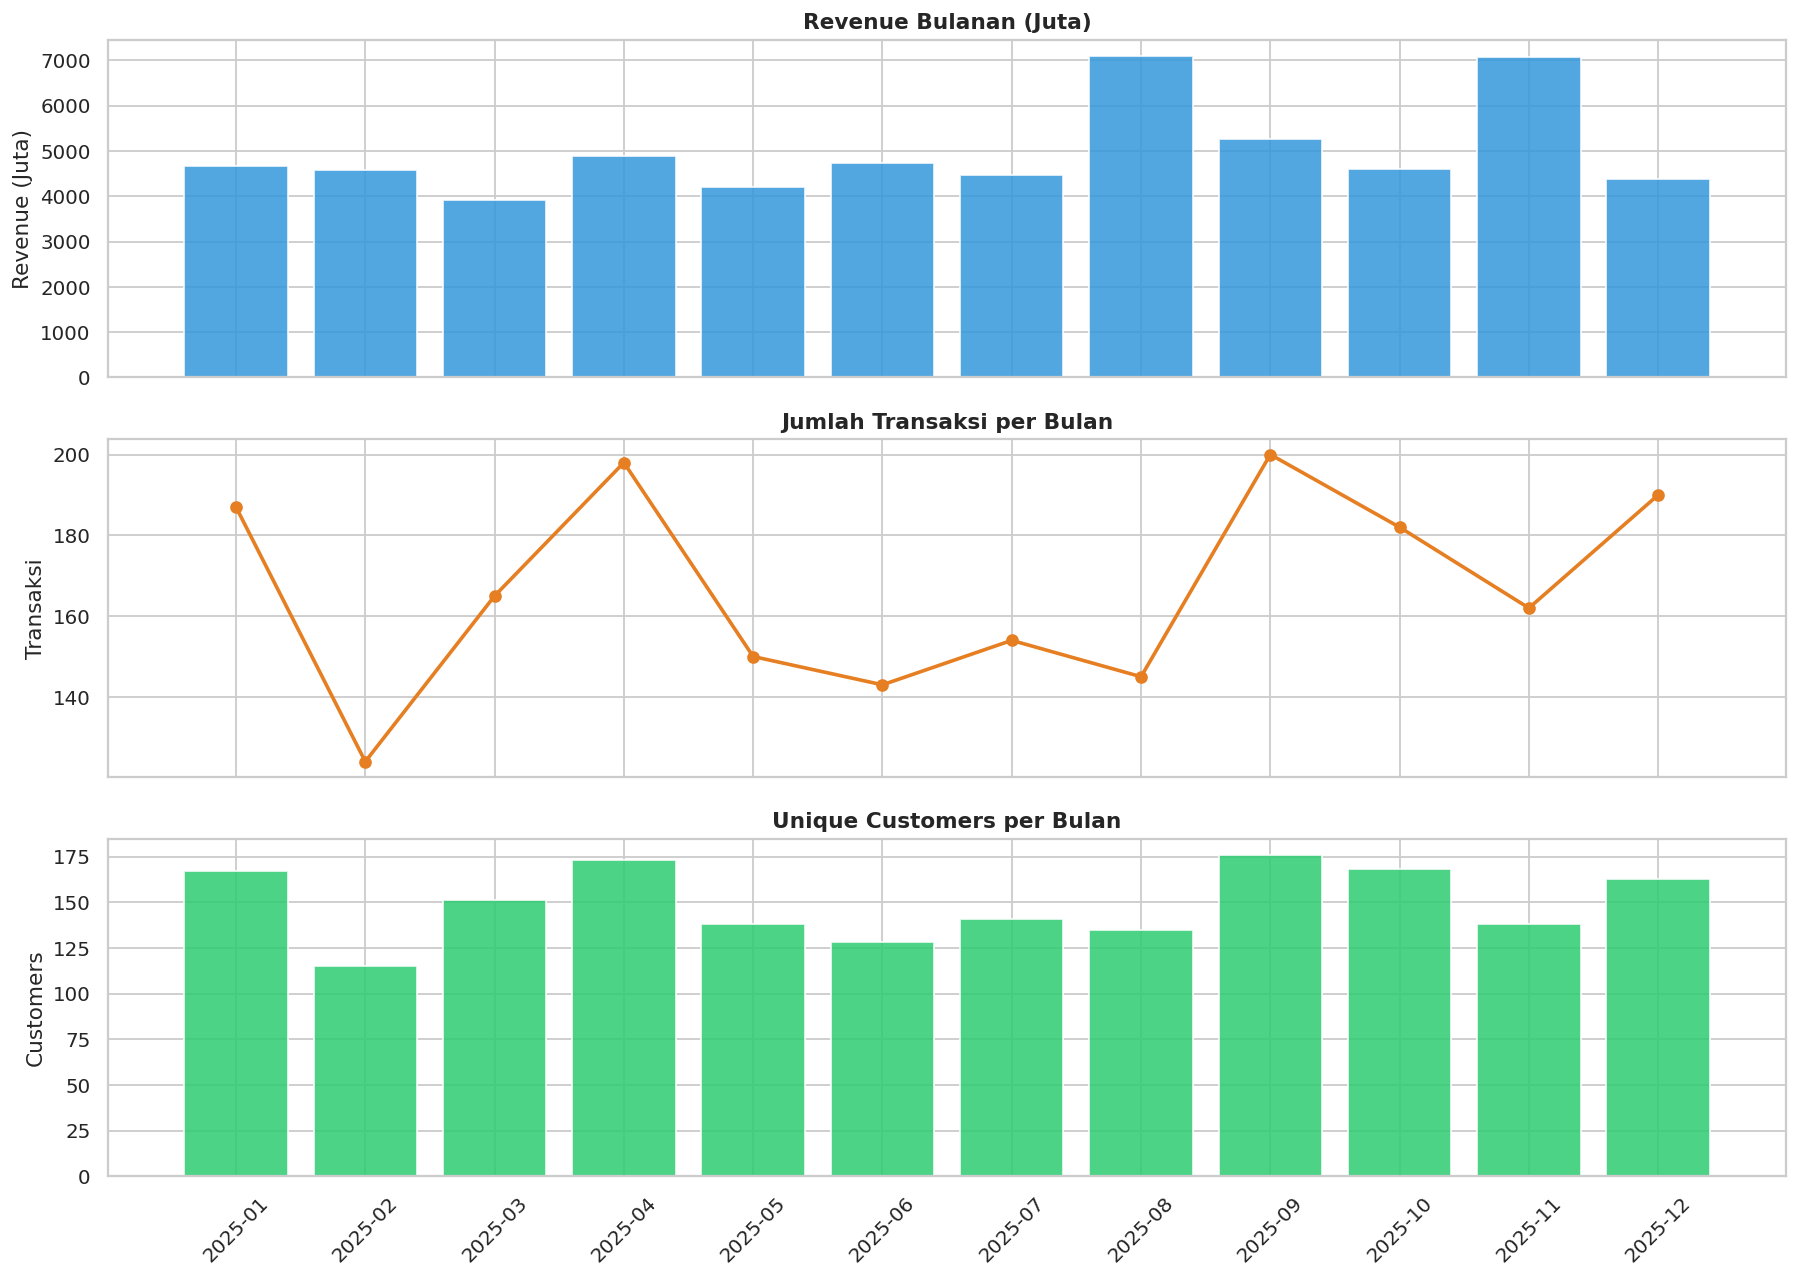

In [13]:
monthly = df.groupby(df['date'].dt.to_period('M')).agg(
    revenue=('amount', 'sum'),
    transactions=('transaction_id', 'count'),
    customers=('customer_id', 'nunique')
).reset_index()
monthly['date_str'] = monthly['date'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].bar(monthly['date_str'], monthly['revenue']/1e6, color='#3498db', alpha=0.85)
axes[0].set_title('Revenue Bulanan (Juta)', fontweight='bold')
axes[0].set_ylabel('Revenue (Juta)')

axes[1].plot(monthly['date_str'], monthly['transactions'], marker='o', color='#e67e22', linewidth=2)
axes[1].set_title('Jumlah Transaksi per Bulan', fontweight='bold')
axes[1].set_ylabel('Transaksi')

axes[2].bar(monthly['date_str'], monthly['customers'], color='#2ecc71', alpha=0.85)
axes[2].set_title('Unique Customers per Bulan', fontweight='bold')
axes[2].set_ylabel('Customers')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 3.3 Revenue per Region & Kategori

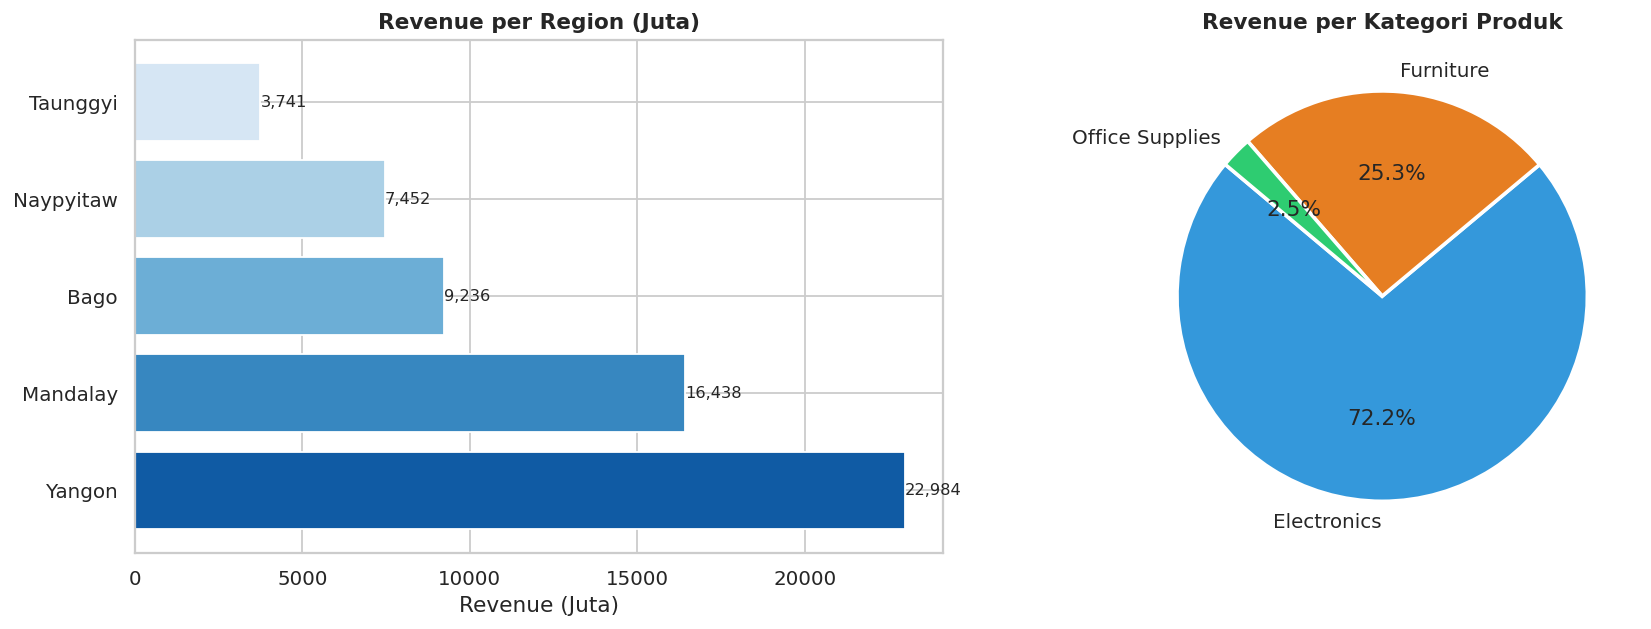

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rev_region = df.groupby('region')['amount'].sum().sort_values(ascending=False) / 1e6
axes[0].barh(rev_region.index, rev_region.values, color=sns.color_palette('Blues_r', len(rev_region)))
axes[0].set_title('Revenue per Region (Juta)', fontweight='bold')
axes[0].set_xlabel('Revenue (Juta)')
for i, v in enumerate(rev_region.values):
    axes[0].text(v + 5, i, f'{v:,.0f}', va='center', fontsize=9)

rev_cat = df.groupby('category')['amount'].sum() / 1e6
axes[1].pie(rev_cat, labels=rev_cat.index, autopct='%1.1f%%',
            colors=['#3498db','#e67e22','#2ecc71'], startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Revenue per Kategori Produk', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Top 10 Produk

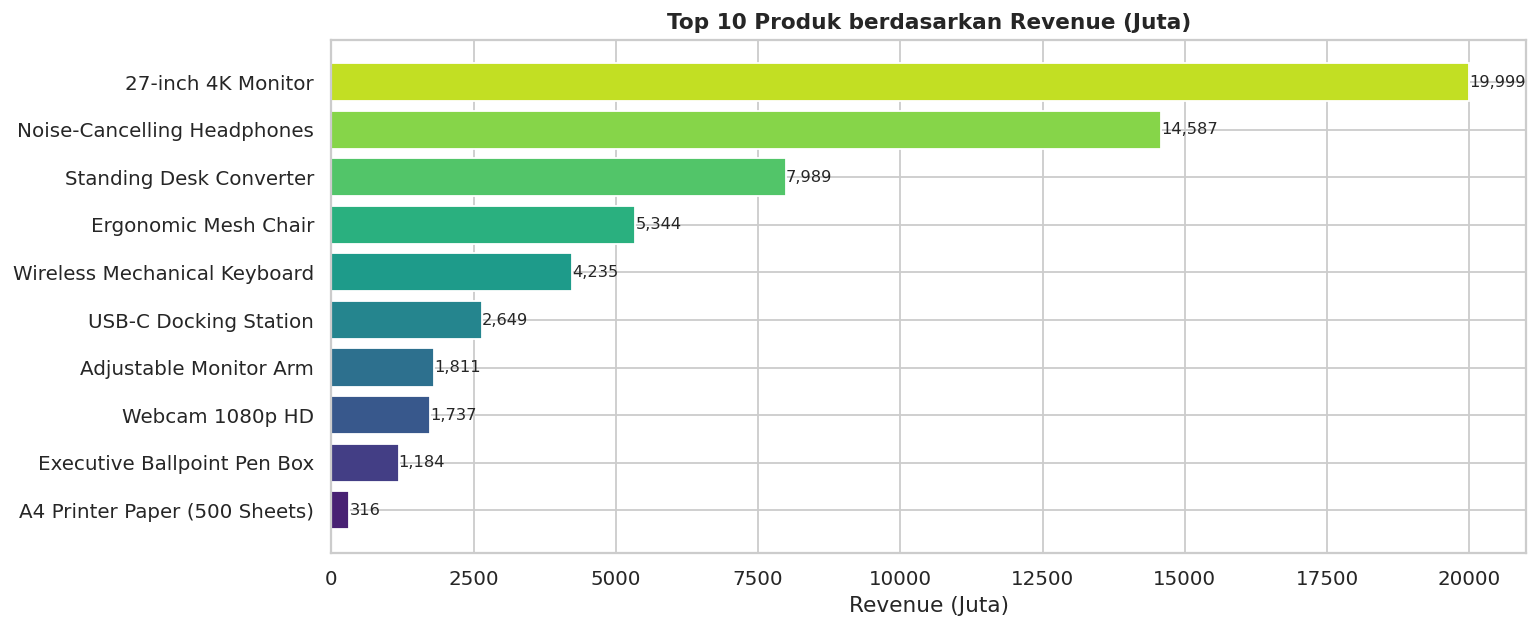

In [15]:
top_products = df.groupby('product_name')['amount'].sum().sort_values(ascending=False).head(10) / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1],
               color=sns.color_palette('viridis', 10))
ax.set_title('Top 10 Produk berdasarkan Revenue (Juta)', fontweight='bold')
ax.set_xlabel('Revenue (Juta)')
for bar, val in zip(bars, top_products.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Distribusi Customer — Frekuensi & Spend

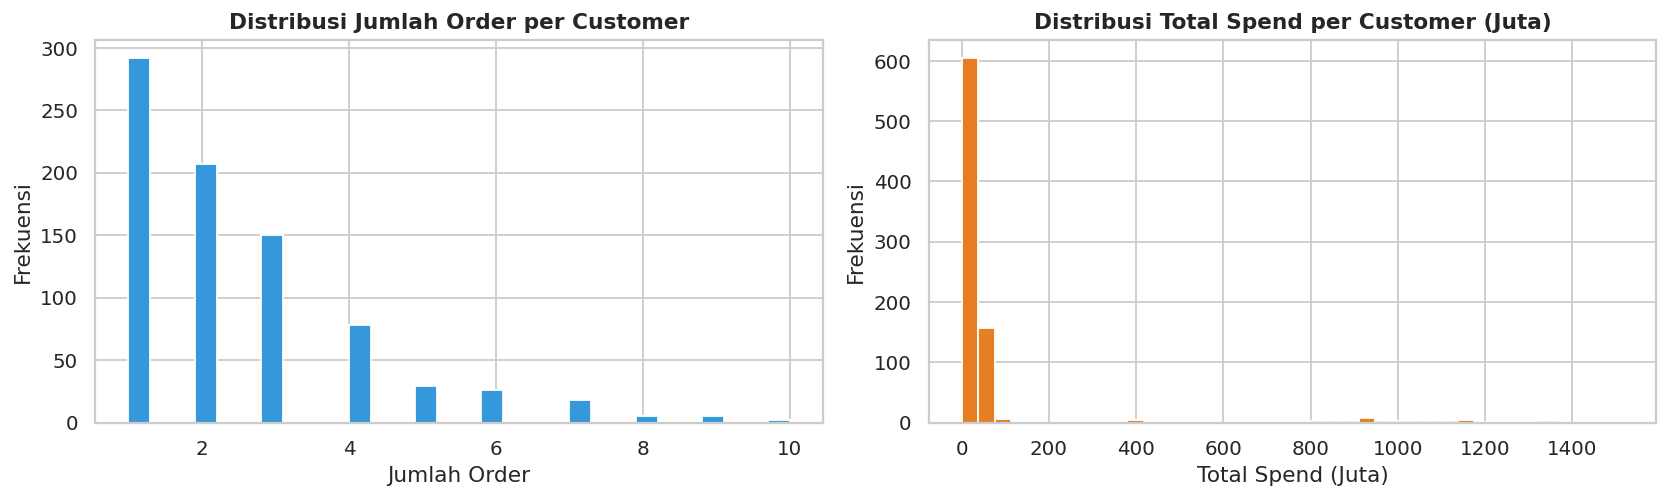

      total_orders      total_spend
count        812.0            812.0
mean           2.5     73,708,867.0
std            1.7    222,021,280.6
min            1.0        250,000.0
25%            1.0      8,538,750.0
50%            2.0     18,350,000.0
75%            3.0     38,738,750.0
max           10.0  1,516,250,000.0


In [16]:
cust_agg = df.groupby('customer_id').agg(
    total_orders=('transaction_id', 'count'),
    total_spend=('amount', 'sum')
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(cust_agg['total_orders'], bins=30, color='#3498db', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Order per Customer', fontweight='bold')
axes[0].set_xlabel('Jumlah Order')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(cust_agg['total_spend']/1e6, bins=40, color='#e67e22', edgecolor='white')
axes[1].set_title('Distribusi Total Spend per Customer (Juta)', fontweight='bold')
axes[1].set_xlabel('Total Spend (Juta)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(cust_agg.describe().map(lambda x: f'{x:,.1f}'))

---
## 4. RFM Calculation

> **RFM** mengukur tiga dimensi perilaku pelanggan:
> - **Recency (R)** — Seberapa baru terakhir kali mereka bertransaksi?
> - **Frequency (F)** — Seberapa sering mereka bertransaksi?
> - **Monetary (M)** — Seberapa besar total belanja mereka?

In [17]:
# Snapshot date = hari setelah tanggal transaksi terakhir
snapshot_date = df['date'].max() + timedelta(days=1)
print(f'Snapshot date: {snapshot_date.date()}')

rfm = df.groupby('customer_id').agg(
    recency   = ('date',           lambda x: (snapshot_date - x.max()).days),
    frequency = ('transaction_id', 'count'),
    monetary  = ('amount',         'sum')
).reset_index()

rfm['monetary_m'] = rfm['monetary'] / 1e6  # satuan juta

print(f'\nJumlah customers: {len(rfm)}')
rfm.head()

Snapshot date: 2026-01-01

Jumlah customers: 812


,customer_id,recency,frequency,monetary,monetary_m
0,Customer-002,7,3,17425000.0,17.425
1,Customer-004,58,5,69590000.0,69.590
2,Customer-005,101,2,22950000.0,22.950
3,Customer-006,301,1,39900000.0,39.900
4,Customer-007,189,1,250000.0,0.250


In [18]:
print('Statistik RFM:')
rfm[['recency','frequency','monetary_m']].describe().round(2)

Statistik RFM:


,recency,frequency,monetary_m
count,812.00,812.00,812.00
mean,122.27,2.46,73.71
std,99.16,1.67,222.02
min,1.00,1.00,0.25
25%,41.00,1.00,8.54
50%,94.00,2.00,18.35
75%,190.00,3.00,38.74
max,365.00,10.00,1516.25


### 4.1 Distribusi RFM

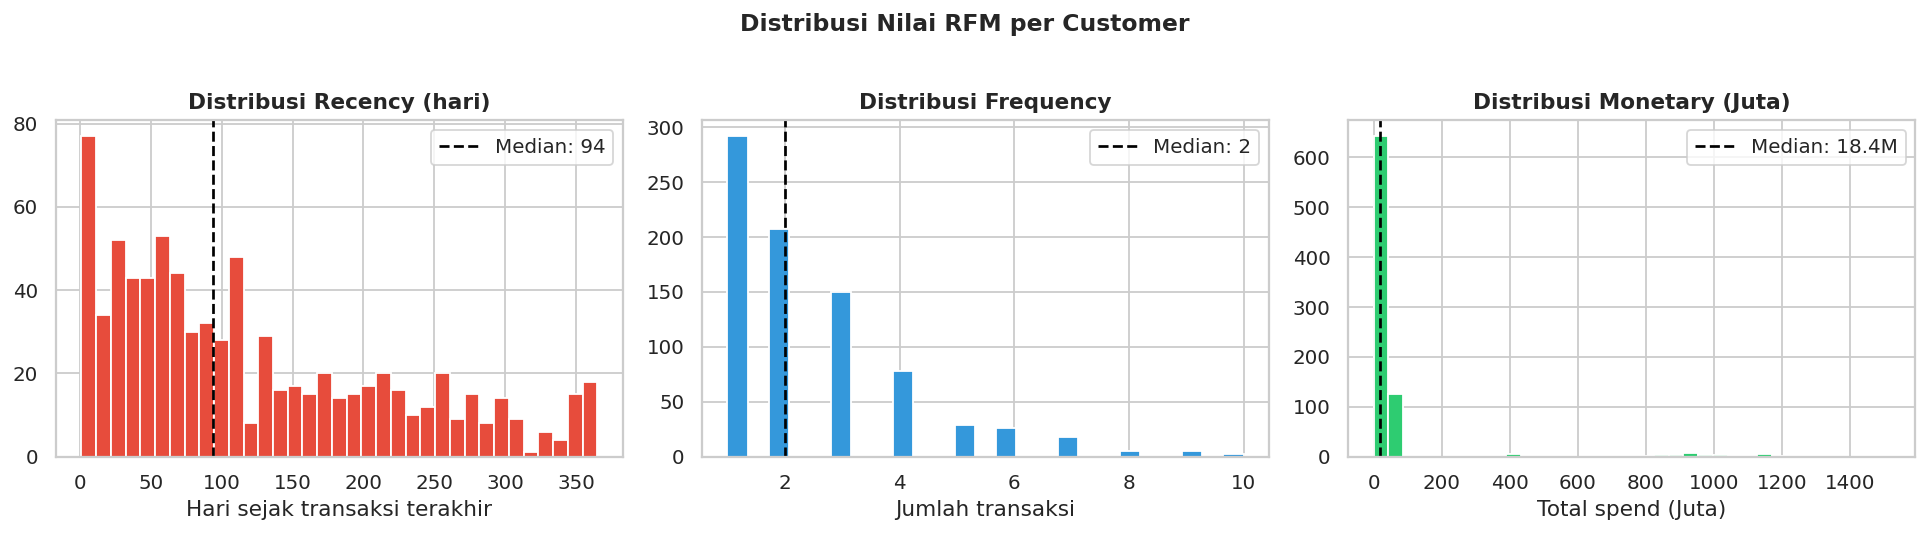

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['recency'], bins=35, color='#e74c3c', edgecolor='white')
axes[0].set_title('Distribusi Recency (hari)', fontweight='bold')
axes[0].set_xlabel('Hari sejak transaksi terakhir')
axes[0].axvline(rfm['recency'].median(), color='black', linestyle='--', label=f'Median: {rfm["recency"].median():.0f}')
axes[0].legend()

axes[1].hist(rfm['frequency'], bins=25, color='#3498db', edgecolor='white')
axes[1].set_title('Distribusi Frequency', fontweight='bold')
axes[1].set_xlabel('Jumlah transaksi')
axes[1].axvline(rfm['frequency'].median(), color='black', linestyle='--', label=f'Median: {rfm["frequency"].median():.0f}')
axes[1].legend()

axes[2].hist(rfm['monetary_m'], bins=35, color='#2ecc71', edgecolor='white')
axes[2].set_title('Distribusi Monetary (Juta)', fontweight='bold')
axes[2].set_xlabel('Total spend (Juta)')
axes[2].axvline(rfm['monetary_m'].median(), color='black', linestyle='--', label=f'Median: {rfm["monetary_m"].median():.1f}M')
axes[2].legend()

plt.suptitle('Distribusi Nilai RFM per Customer', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. RFM Scoring (Kuintil 1–5)

> Setiap metrik dibagi ke 5 kuintil (skor 1–5).
> - **R**: semakin kecil hari = semakin bagus → skor 5 untuk terkecil.
> - **F & M**: semakin besar = semakin bagus → skor 5 untuk terbesar.

In [20]:
# Fungsi scoring
def quintile_score(series, reverse=False, n=5):
    """Bagi series ke n kuintil, return skor 1..n.
    reverse=True: nilai kecil = skor tinggi (untuk Recency)."""
    labels = list(range(n, 0, -1)) if reverse else list(range(1, n+1))
    try:
        return pd.qcut(series, q=n, labels=labels, duplicates='drop')
    except ValueError:
        # Fallback rank-based jika ada terlalu banyak nilai sama
        return pd.cut(series.rank(method='first'), bins=n, labels=labels)

rfm['R_score'] = quintile_score(rfm['recency'],   reverse=True).astype(int)
rfm['F_score'] = quintile_score(rfm['frequency'],  reverse=False).astype(int)
rfm['M_score'] = quintile_score(rfm['monetary_m'], reverse=False).astype(int)

# RFM Score gabungan
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

print('Distribusi skor RFM:')
print(rfm[['R_score','F_score','M_score','RFM_total']].describe().round(2))
rfm[['customer_id','recency','frequency','monetary_m','R_score','F_score','M_score','RFM_score','RFM_total']].head(10)

Distribusi skor RFM:
       R_score  F_score  M_score  RFM_total
count   812.00   812.00   812.00     812.00
mean      3.01     3.00     3.00       9.01
std       1.41     1.42     1.42       3.37
min       1.00     1.00     1.00       3.00
25%       2.00     2.00     2.00       6.00
50%       3.00     3.00     3.00       9.00
75%       4.00     4.00     4.00      12.00
max       5.00     5.00     5.00      15.00


,customer_id,recency,frequency,monetary_m,R_score,F_score,M_score,RFM_score,RFM_total
0,Customer-002,7,3,17.425,5,4,3,543,12
1,Customer-004,58,5,69.590,4,5,5,455,14
2,Customer-005,101,2,22.950,3,2,3,323,8
3,Customer-006,301,1,39.900,1,1,4,114,6
4,Customer-007,189,1,0.250,2,1,1,211,4
5,Customer-008,296,1,19.000,1,1,3,113,5
6,Customer-009,255,2,11.700,1,2,2,122,5
7,Customer-012,73,3,10.230,3,4,2,342,9
8,Customer-013,45,3,60.960,4,4,5,445,13
9,Customer-014,99,1,18.450,3,1,3,313,7


---
## 6. Customer Segmentation

### 6.1 Definisi Segmen (Rule-Based)

In [21]:
def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalist'
    elif r >= 3 and f <= 2 and m <= 2:
        return 'Promising'
    elif r == 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r == 2 and f <= 2 and m <= 2:
        return 'About To Sleep'
    elif r <= 2 and f >= 3 and m <= 2:
        return 'Need Attention'
    elif r == 1 and f >= 3:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

seg_counts = rfm['segment'].value_counts()
print('Jumlah customers per segmen:')
print(seg_counts.to_string())

Jumlah customers per segmen:
segment
Lost                  157
Loyal Customers       150
Champions             139
New Customers          78
At Risk                72
Potential Loyalist     68
About To Sleep         61
Need Attention         28
Promising              28
Hibernating            25
Cant Lose Them          6


### 6.2 Distribusi Segmen

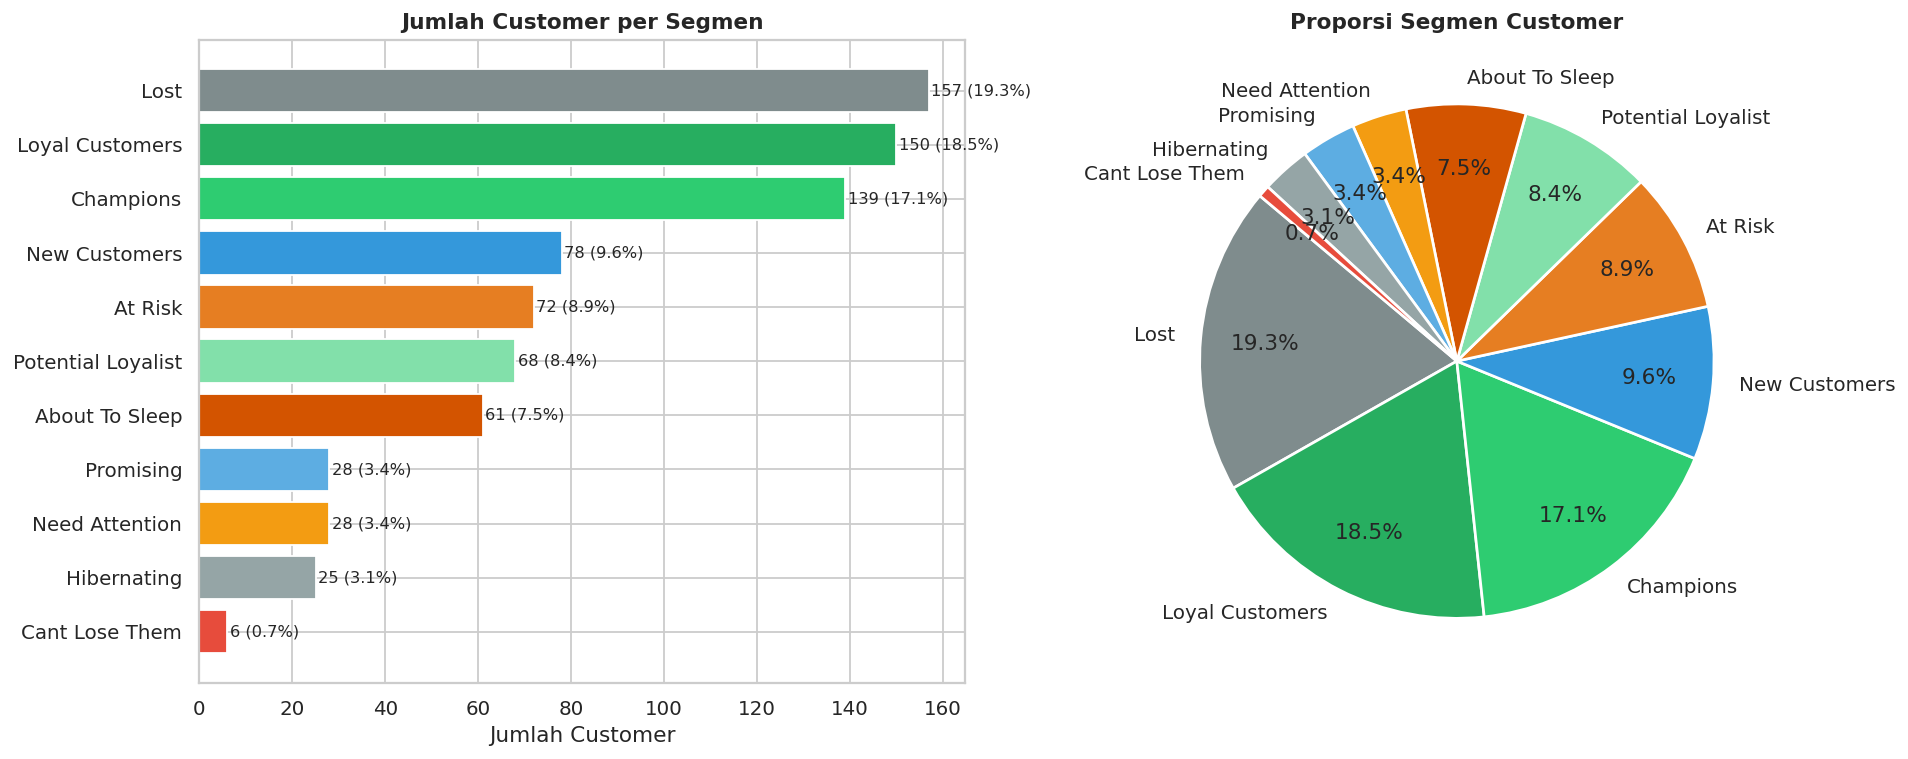

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
seg_sorted = seg_counts.sort_values(ascending=True)
colors_bar = [PALETTE.get(s, '#95a5a6') for s in seg_sorted.index]
bars = axes[0].barh(seg_sorted.index, seg_sorted.values, color=colors_bar)
axes[0].set_title('Jumlah Customer per Segmen', fontweight='bold')
axes[0].set_xlabel('Jumlah Customer')
for bar, val in zip(bars, seg_sorted.values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val} ({val/len(rfm)*100:.1f}%)', va='center', fontsize=9)

# Pie chart
colors_pie = [PALETTE.get(s, '#95a5a6') for s in seg_counts.index]
axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':1.5}, pctdistance=0.75)
axes[1].set_title('Proporsi Segmen Customer', fontweight='bold')

plt.tight_layout()
plt.show()

### 6.3 Profil RFM per Segmen

In [23]:
seg_profile = rfm.groupby('segment').agg(
    customers  = ('customer_id', 'count'),
    avg_recency= ('recency',    'mean'),
    avg_freq   = ('frequency',  'mean'),
    avg_monetary_m = ('monetary_m', 'mean'),
    total_revenue_m= ('monetary_m', 'sum')
).round(1).sort_values('total_revenue_m', ascending=False)

seg_profile['revenue_%'] = (seg_profile['total_revenue_m'] /
                             seg_profile['total_revenue_m'].sum() * 100).round(1)
print(seg_profile.to_string())

                    customers  avg_recency  avg_freq  avg_monetary_m  total_revenue_m  revenue_%
segment                                                                                         
Champions                 139         31.1       4.7           272.1          37815.7       63.2
Loyal Customers           150         63.1       3.1            74.8          11218.4       18.7
At Risk                    72        160.8       3.2            70.2           5055.9        8.4
Lost                      157        248.6       1.2            13.0           2035.0        3.4
New Customers              78         39.1       1.2            15.5           1206.6        2.0
Potential Loyalist         68         74.2       2.1            11.7            797.7        1.3
Hibernating                25        255.5       2.2            28.1            703.5        1.2
About To Sleep             61        176.5       1.1             5.5            335.0        0.6
Cant Lose Them              6 

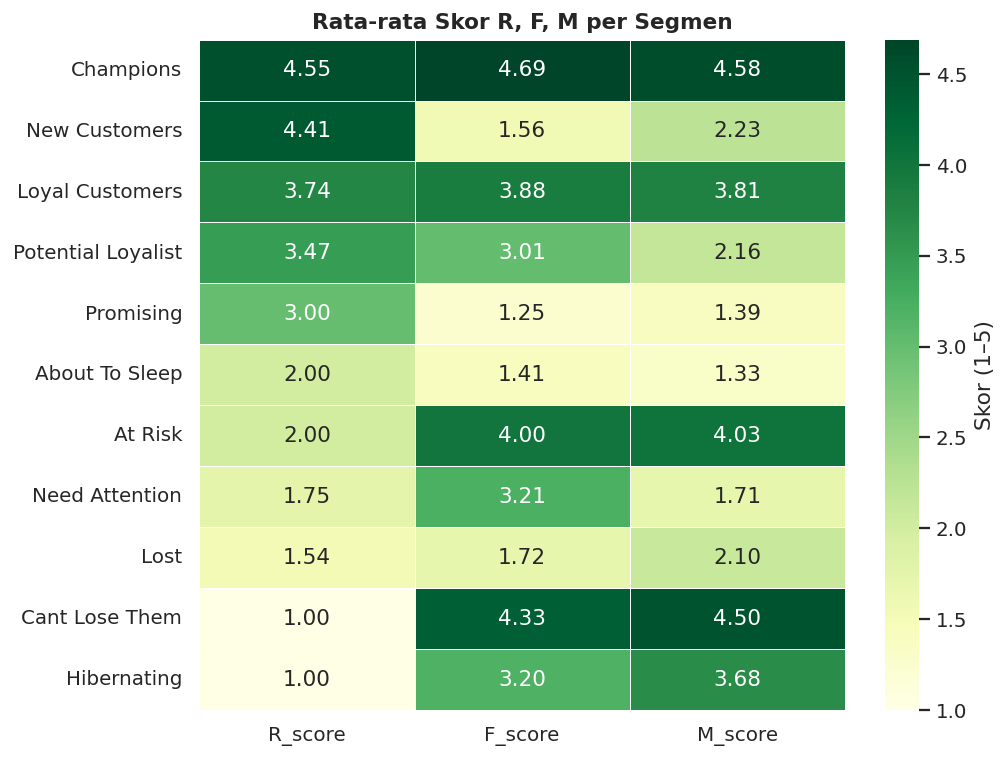

In [24]:
# Heatmap rata-rata skor per segmen
score_heat = rfm.groupby('segment')[['R_score','F_score','M_score']].mean().round(2)
score_heat = score_heat.sort_values('R_score', ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(score_heat, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Skor (1–5)'})
plt.title('Rata-rata Skor R, F, M per Segmen', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### 6.4 Revenue per Segmen

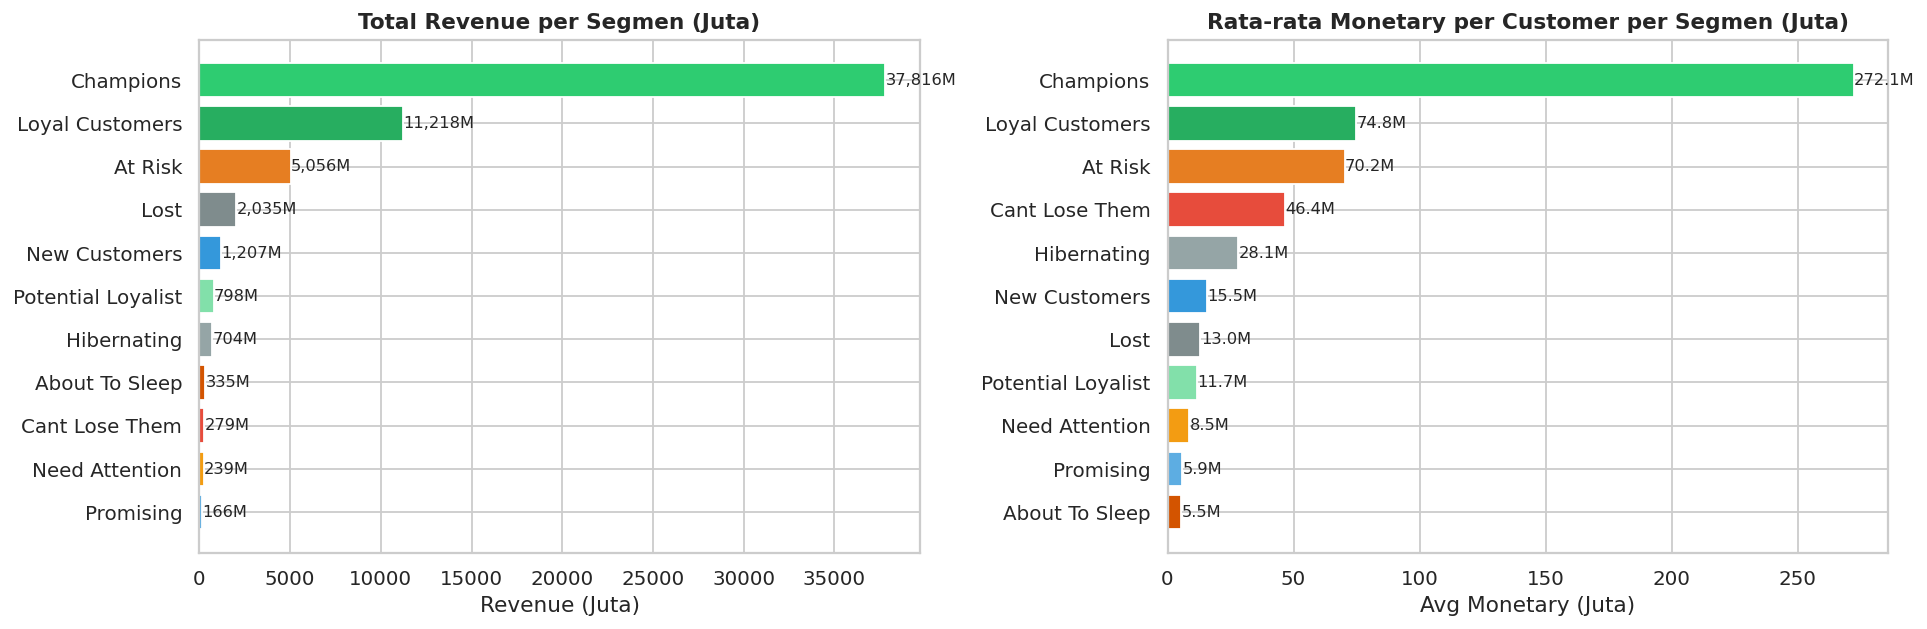

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Total revenue
rev_seg = seg_profile['total_revenue_m'].sort_values(ascending=True)
colors_rev = [PALETTE.get(s, '#95a5a6') for s in rev_seg.index]
axes[0].barh(rev_seg.index, rev_seg.values, color=colors_rev)
axes[0].set_title('Total Revenue per Segmen (Juta)', fontweight='bold')
axes[0].set_xlabel('Revenue (Juta)')
for i, v in enumerate(rev_seg.values):
    axes[0].text(v + 1, i, f'{v:,.0f}M', va='center', fontsize=9)

# Avg monetary
avg_m = seg_profile['avg_monetary_m'].sort_values(ascending=True)
colors_avg = [PALETTE.get(s, '#95a5a6') for s in avg_m.index]
axes[1].barh(avg_m.index, avg_m.values, color=colors_avg)
axes[1].set_title('Rata-rata Monetary per Customer per Segmen (Juta)', fontweight='bold')
axes[1].set_xlabel('Avg Monetary (Juta)')
for i, v in enumerate(avg_m.values):
    axes[1].text(v + 0.2, i, f'{v:,.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 6.5 Scatter Plot RFM 2D

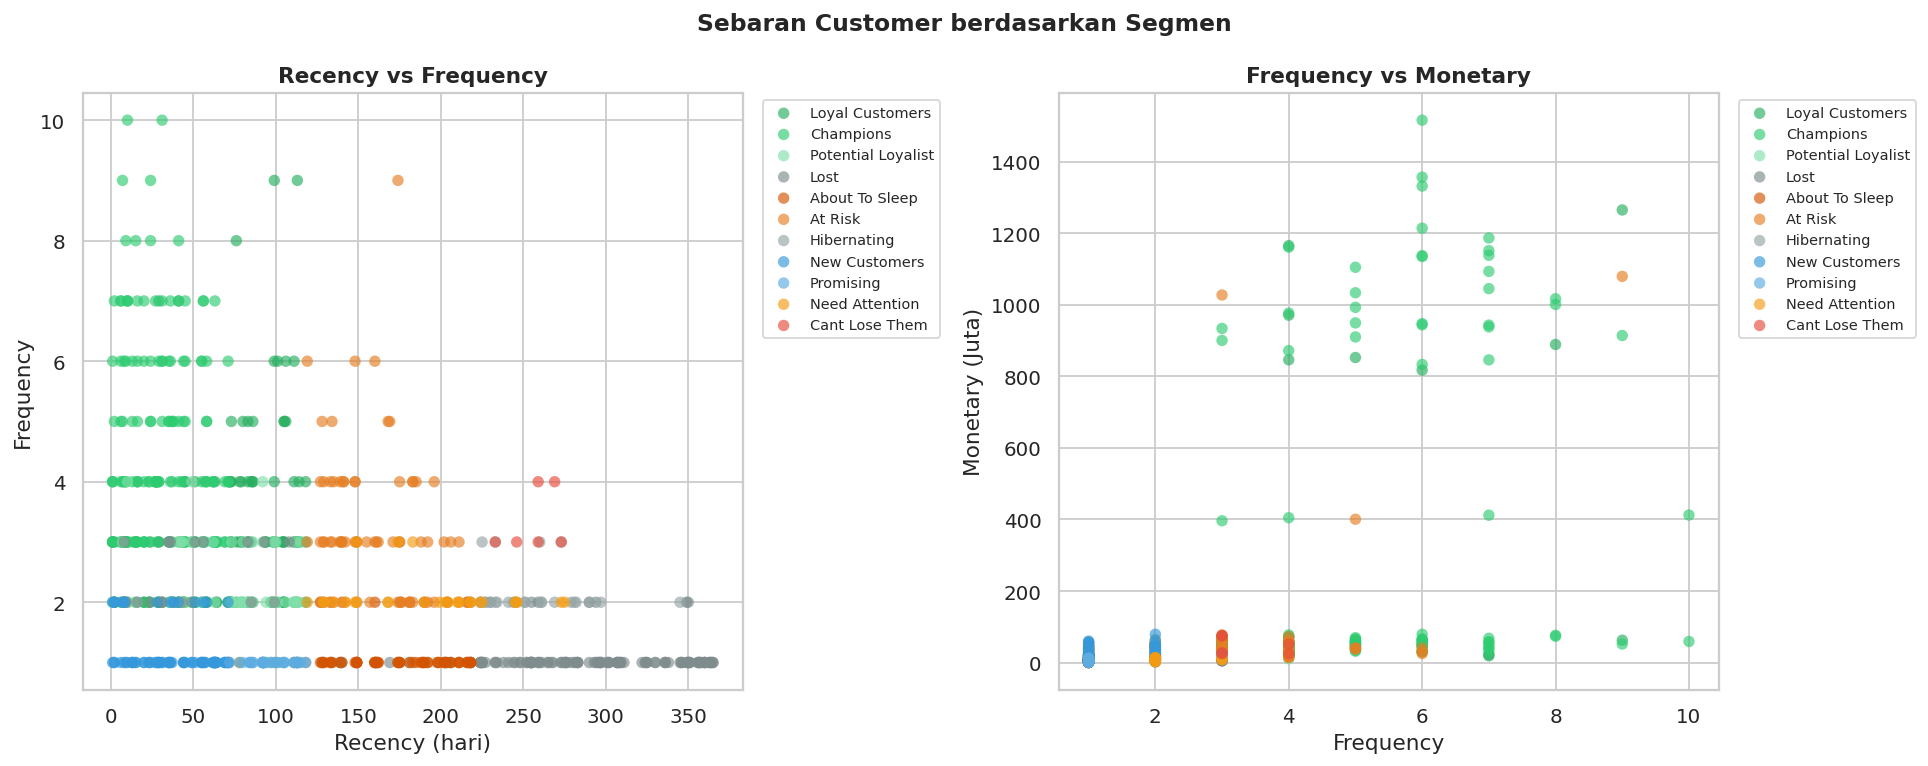

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

segments = rfm['segment'].unique()
color_map = {s: PALETTE.get(s, '#95a5a6') for s in segments}

for seg in segments:
    mask = rfm['segment'] == seg
    axes[0].scatter(rfm[mask]['recency'], rfm[mask]['frequency'],
                    c=color_map[seg], label=seg, alpha=0.65, s=40, edgecolors='none')
axes[0].set_xlabel('Recency (hari)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

for seg in segments:
    mask = rfm['segment'] == seg
    axes[1].scatter(rfm[mask]['frequency'], rfm[mask]['monetary_m'],
                    c=color_map[seg], label=seg, alpha=0.65, s=40, edgecolors='none')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (Juta)')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.suptitle('Sebaran Customer berdasarkan Segmen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.6 Treemap — Kontribusi Revenue

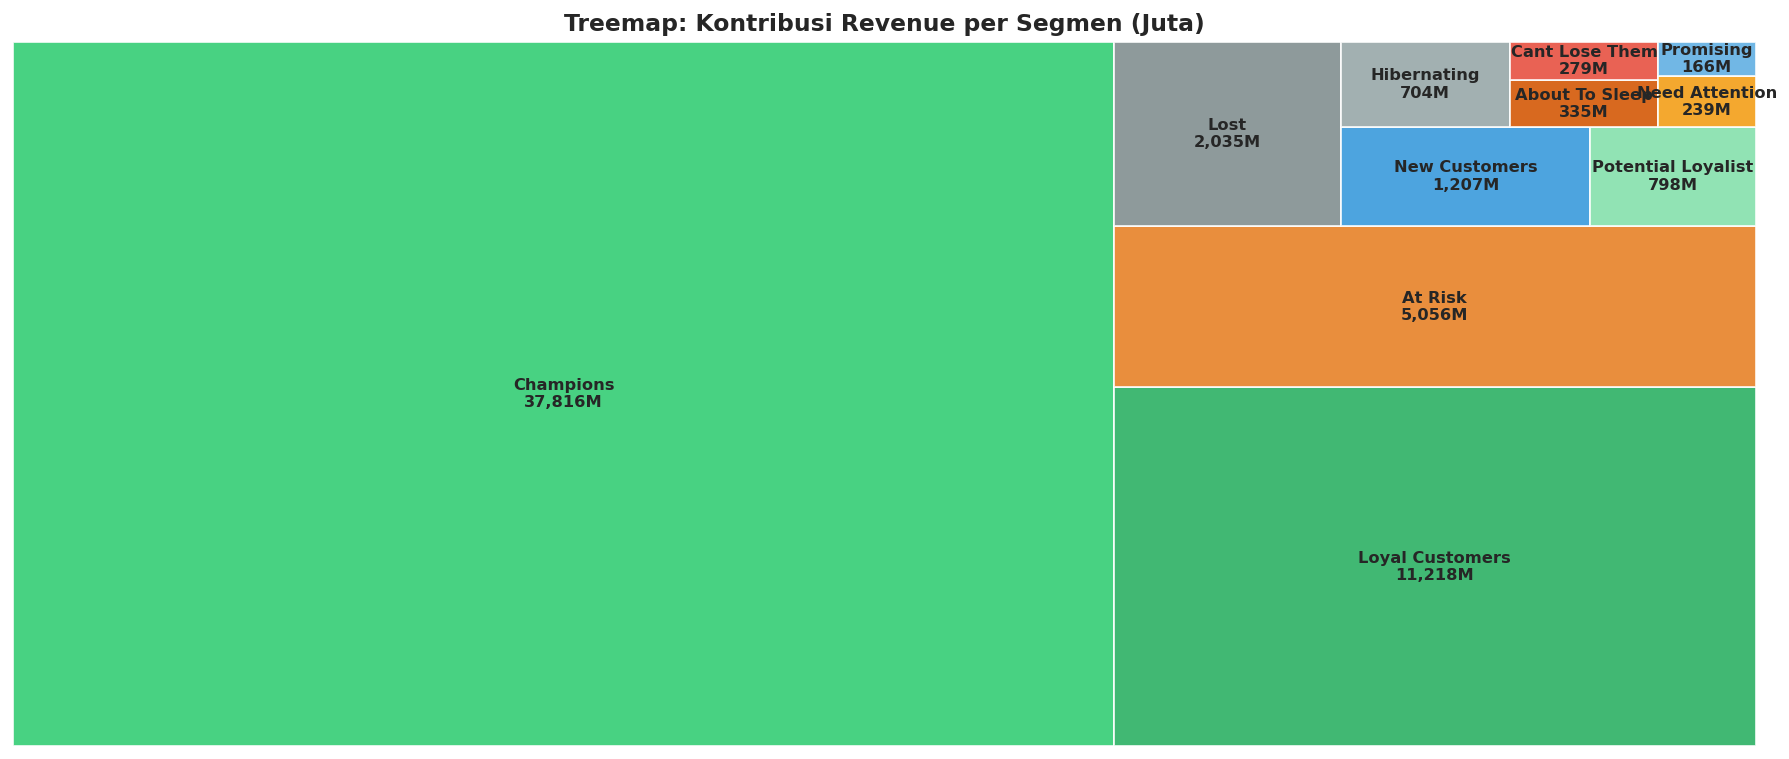

In [27]:
try:
    import squarify
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'squarify', '-q'])
    import squarify

rev_tree = rfm.groupby('segment')['monetary_m'].sum().sort_values(ascending=False)
colors_tree = [PALETTE.get(s, '#95a5a6') for s in rev_tree.index]
labels = [f"{s}\n{v:,.0f}M" for s, v in zip(rev_tree.index, rev_tree.values)]

plt.figure(figsize=(14, 6))
squarify.plot(sizes=rev_tree.values, label=labels, color=colors_tree,
              alpha=0.88, text_kwargs={'fontsize': 9, 'fontweight': 'bold'})
plt.title('Treemap: Kontribusi Revenue per Segmen (Juta)', fontweight='bold', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## 7. Analisis Lanjutan

### 7.1 Segmen per Region

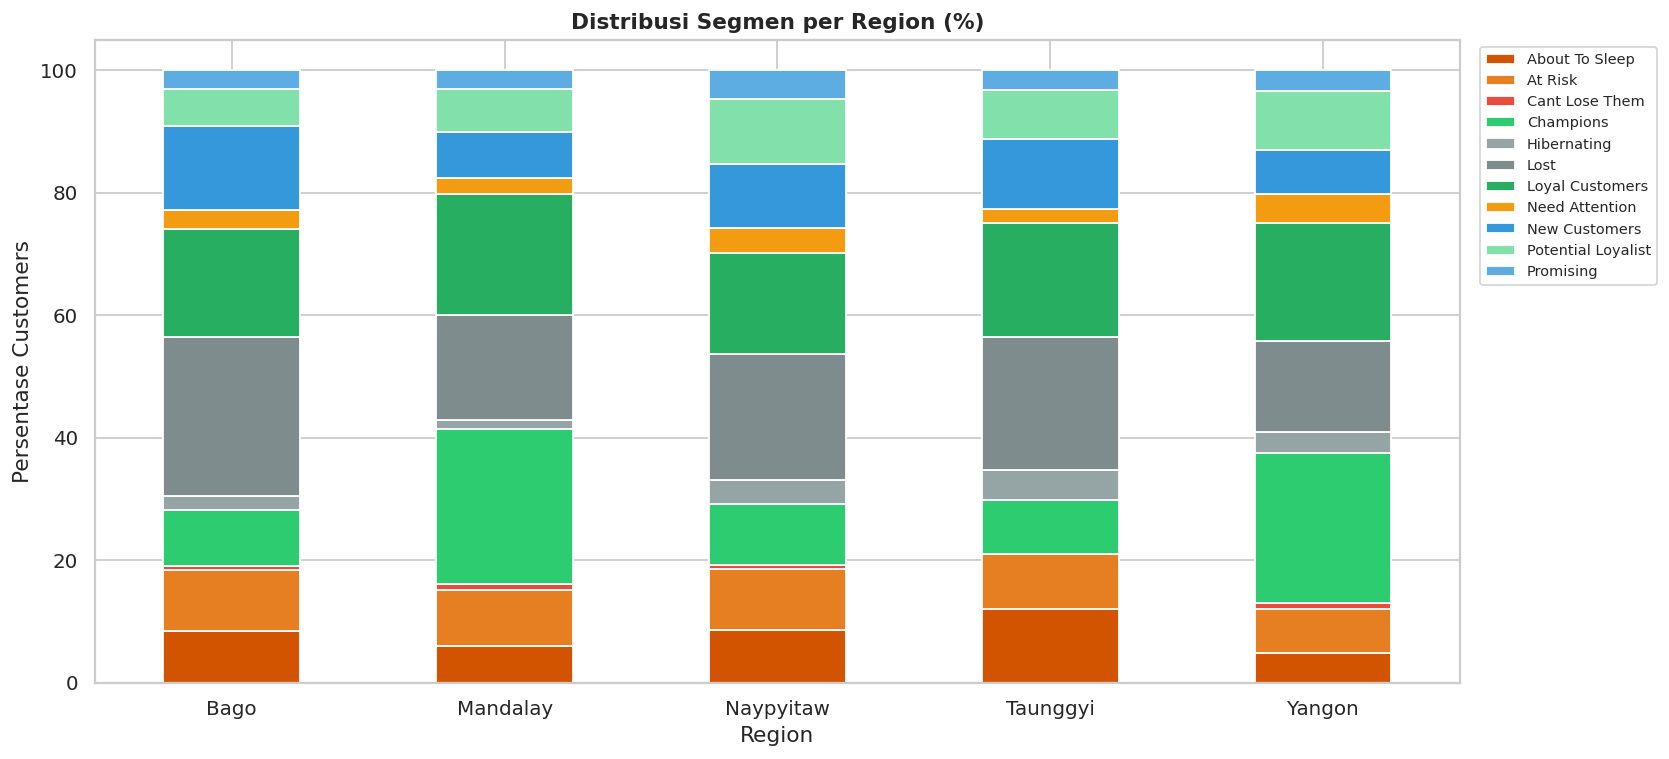

In [28]:
# Gabung region ke RFM
cust_region = df.groupby('customer_id')['region'].agg(lambda x: x.mode()[0]).reset_index()
rfm_r = rfm.merge(cust_region, on='customer_id', how='left')

pivot_region = rfm_r.groupby(['region','segment']).size().unstack(fill_value=0)
pivot_region_pct = pivot_region.div(pivot_region.sum(axis=1), axis=0) * 100

pivot_region_pct.plot(kind='bar', stacked=True, figsize=(13, 6),
                      color=[PALETTE.get(c, '#95a5a6') for c in pivot_region_pct.columns])
plt.title('Distribusi Segmen per Region (%)', fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Persentase Customers')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 7.2 Segmen per Kategori Produk Favorit

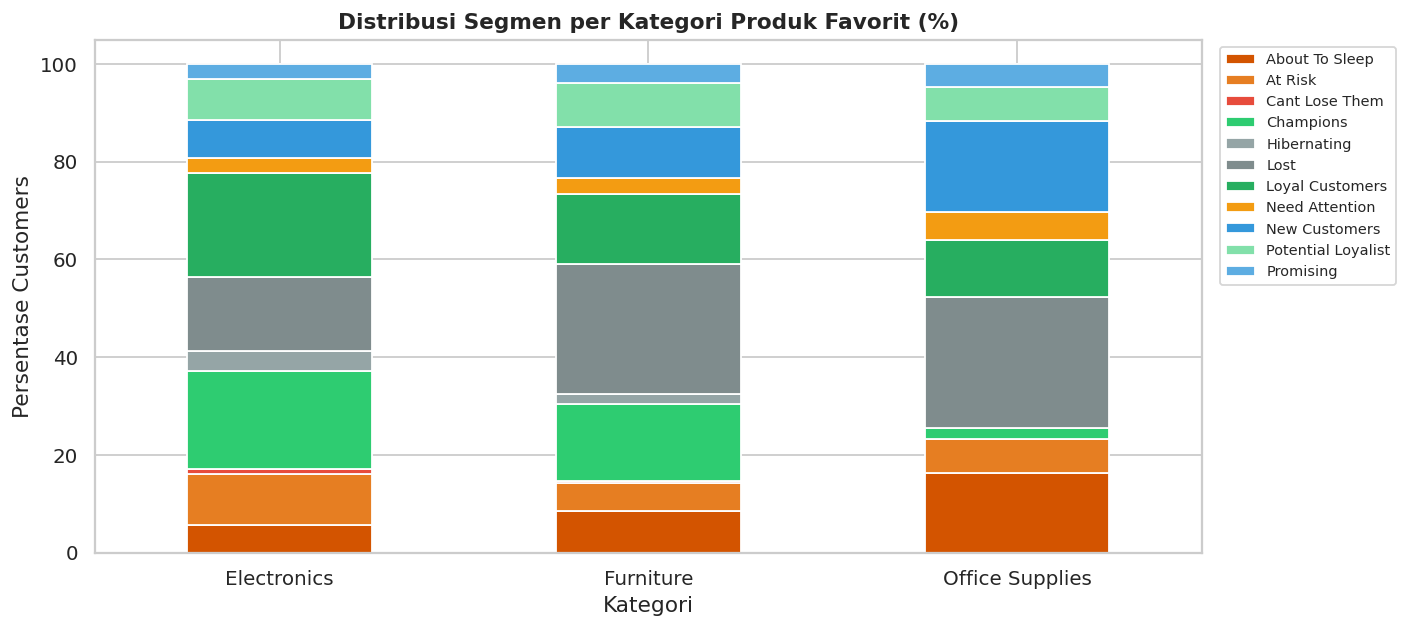

In [29]:
cust_cat = df.groupby('customer_id')['category'].agg(lambda x: x.mode()[0]).reset_index()
cust_cat.columns = ['customer_id', 'fav_category']
rfm_rc = rfm_r.merge(cust_cat, on='customer_id', how='left')

pivot_cat = rfm_rc.groupby(['fav_category','segment']).size().unstack(fill_value=0)
pivot_cat_pct = pivot_cat.div(pivot_cat.sum(axis=1), axis=0) * 100

pivot_cat_pct.plot(kind='bar', stacked=True, figsize=(11, 5),
                   color=[PALETTE.get(c, '#95a5a6') for c in pivot_cat_pct.columns])
plt.title('Distribusi Segmen per Kategori Produk Favorit (%)', fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Persentase Customers')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

### 7.3 RFM Snake Plot (Normalisasi)

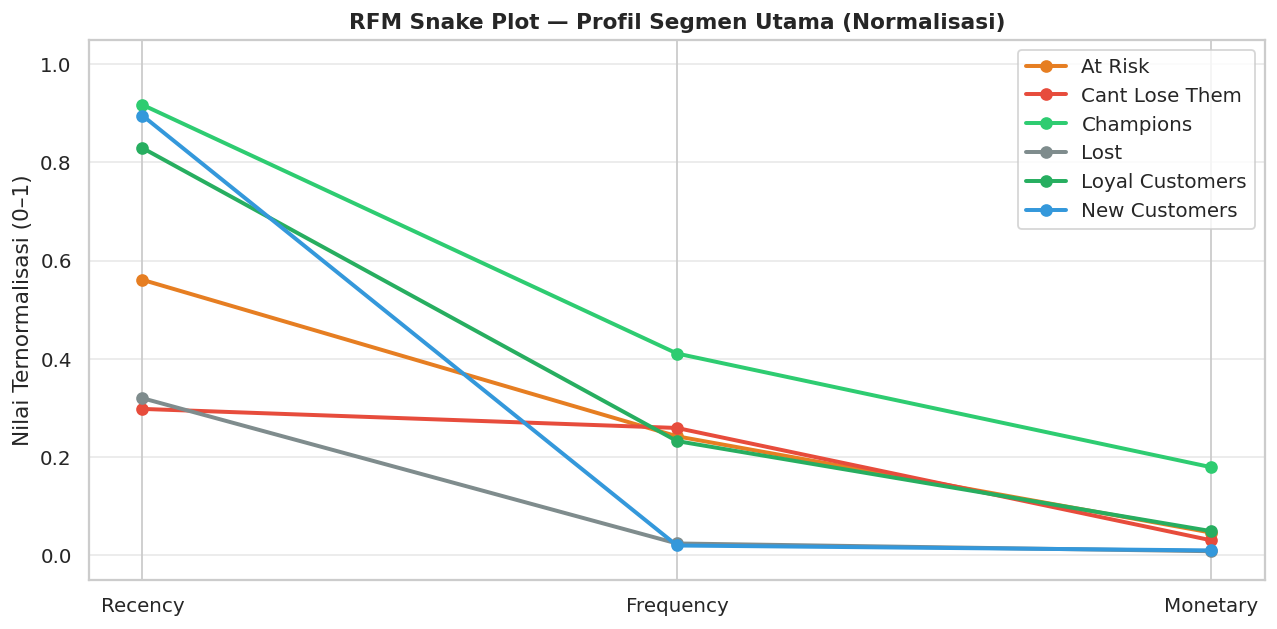

In [30]:
from sklearn.preprocessing import MinMaxScaler

# Pilih segmen utama
key_segments = ['Champions','Loyal Customers','At Risk','Cant Lose Them','Lost','New Customers']
rfm_key = rfm[rfm['segment'].isin(key_segments)].copy()

scaler = MinMaxScaler()
rfm_key[['R_norm','F_norm','M_norm']] = scaler.fit_transform(
    rfm_key[['recency','frequency','monetary_m']] * np.array([-1, 1, 1])  # invert recency
)

snake = rfm_key.groupby('segment')[['R_norm','F_norm','M_norm']].mean()
snake.columns = ['Recency','Frequency','Monetary']

plt.figure(figsize=(10, 5))
for seg, row in snake.iterrows():
    plt.plot(['Recency','Frequency','Monetary'], row.values,
             marker='o', linewidth=2.2, label=seg,
             color=PALETTE.get(seg, '#95a5a6'))
plt.title('RFM Snake Plot — Profil Segmen Utama (Normalisasi)', fontweight='bold')
plt.ylabel('Nilai Ternormalisasi (0–1)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

---
## 8. Business Insights & Rekomendasi Aksi

In [31]:
actions = {
    'Champions'        : '🏆 Reward & VIP program. Minta referral & review produk.',
    'Loyal Customers'  : '💎 Loyalty points. Upsell produk premium & kategori baru.',
    'Potential Loyalist': '📈 Onboarding email series. Dorong second purchase dengan diskon.',
    'New Customers'    : '🆕 Welcome flow. Edukasi produk & guidance pertama.',
    'Promising'        : '✨ Kampanye engagement ringan. Showcase produk terpopuler.',
    'At Risk'          : '⚠️  Re-engagement campaign. Survei kepuasan & penawaran khusus.',
    'Cant Lose Them'   : '🚨 Hubungi secara personal. Tawarkan win-back deal eksklusif.',
    'Need Attention'   : '📣 Push notifikasi & email reminder manfaat produk.',
    'About To Sleep'   : '😴 Limited time offer sebelum churn. Flash sale pribadi.',
    'Hibernating'      : '❄️  Re-aktivasi minimal cost. Promo agresif jika margin memadai.',
    'Lost'             : '💀 Analisis penyebab churn. Survei keluar. Realokasi budget.',
}

print('=' * 65)
print('       RINGKASAN SEGMEN & REKOMENDASI AKSI MARKETING')
print('=' * 65)
for seg in seg_profile.index:
    row = seg_profile.loc[seg]
    print(f"\n● {seg}")
    print(f"  Customers    : {int(row['customers']):>4} ({int(row['customers'])/len(rfm)*100:.1f}%)")
    print(f"  Avg Recency  : {row['avg_recency']:.0f} hari")
    print(f"  Avg Frequency: {row['avg_freq']:.1f} transaksi")
    print(f"  Avg Monetary : {row['avg_monetary_m']:.1f} Juta")
    print(f"  Revenue share: {row['revenue_%']:.1f}%")
    print(f"  ➜  {actions.get(seg, 'Analisis lebih lanjut.')}")

       RINGKASAN SEGMEN & REKOMENDASI AKSI MARKETING

● Champions
  Customers    :  139 (17.1%)
  Avg Recency  : 31 hari
  Avg Frequency: 4.7 transaksi
  Avg Monetary : 272.1 Juta
  Revenue share: 63.2%
  ➜  🏆 Reward & VIP program. Minta referral & review produk.

● Loyal Customers
  Customers    :  150 (18.5%)
  Avg Recency  : 63 hari
  Avg Frequency: 3.1 transaksi
  Avg Monetary : 74.8 Juta
  Revenue share: 18.7%
  ➜  💎 Loyalty points. Upsell produk premium & kategori baru.

● At Risk
  Customers    :   72 (8.9%)
  Avg Recency  : 161 hari
  Avg Frequency: 3.2 transaksi
  Avg Monetary : 70.2 Juta
  Revenue share: 8.4%
  ➜  ⚠️  Re-engagement campaign. Survei kepuasan & penawaran khusus.

● Lost
  Customers    :  157 (19.3%)
  Avg Recency  : 249 hari
  Avg Frequency: 1.2 transaksi
  Avg Monetary : 13.0 Juta
  Revenue share: 3.4%
  ➜  💀 Analisis penyebab churn. Survei keluar. Realokasi budget.

● New Customers
  Customers    :   78 (9.6%)
  Avg Recency  : 39 hari
  Avg Frequency: 1.2 tra

---
## 9. Export Hasil

In [32]:
# Gabung semua info relevan
final = rfm_rc[['customer_id','region','fav_category',
                 'recency','frequency','monetary_m',
                 'R_score','F_score','M_score',
                 'RFM_score','RFM_total','segment']].copy()
final.columns = ['Customer ID','Region','Kategori Favorit',
                 'Recency (hari)','Frequency','Monetary (Juta)',
                 'R Score','F Score','M Score',
                 'RFM Code','RFM Total','Segment']

output_path = 'rfm_segmented_customers.csv'
final.to_csv(output_path, index=False)
print(f'✅ File tersimpan: {output_path}')
print(f'   Baris : {len(final):,}')
print(f'   Kolom : {len(final.columns)}')
final.head()

✅ File tersimpan: rfm_segmented_customers.csv
   Baris : 812
   Kolom : 12


,Customer ID,Region,Kategori Favorit,Recency (hari),Frequency,Monetary (Juta),R Score,F Score,M Score,RFM Code,RFM Total,Segment
0,Customer-002,Mandalay,Electronics,7,3,17.425,5,4,3,543,12,Loyal Customers
1,Customer-004,Yangon,Furniture,58,5,69.590,4,5,5,455,14,Champions
2,Customer-005,Mandalay,Electronics,101,2,22.950,3,2,3,323,8,Potential Loyalist
3,Customer-006,Bago,Electronics,301,1,39.900,1,1,4,114,6,Lost
4,Customer-007,Bago,Office Supplies,189,1,0.250,2,1,1,211,4,About To Sleep


---
## 10. Kesimpulan

| Poin | Detail |
|------|--------|
| **Dataset** | 2.000 transaksi, 812 customers unik, periode Jan–Des 2025 |
| **Segmen terbesar** | *Potential Loyalist* & *Loyal Customers* — mayoritas customers cukup aktif |
| **Segmen prioritas revenue** | *Champions* & *Cant Lose Them* — kontribusi revenue besar, perlu proteksi |
| **Tindakan kritis** | Re-engagement *At Risk* & *Cant Lose Them* sebelum benar-benar churn |
| **Peluang growth** | Konversi *Potential Loyalist* → *Loyal Customers* dengan program loyalty |
| **Output** | File CSV hasil segmentasi tersimpan di `rfm_segmented_customers.csv` |

> **Langkah selanjutnya:** Integrasikan segmen ke CRM, otomasi email marketing per segmen, dan lakukan A/B testing campaign untuk setiap tier.